# 1.4.4 Smoothing Images

## Kernel Convolution

In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [3]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [5]:
kernel

array([[0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04]], dtype=float32)

In [6]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [7]:
img

array([[5, 3, 0, 1, 8, 0, 6, 7, 0, 9, 9, 3],
       [1, 1, 2, 3, 8, 6, 3, 9, 9, 2, 4, 4],
       [6, 3, 3, 9, 4, 7, 3, 6, 1, 4, 2, 5],
       [1, 1, 1, 5, 4, 5, 8, 4, 4, 2, 7, 6],
       [9, 4, 7, 2, 5, 9, 5, 2, 3, 6, 3, 4],
       [8, 1, 6, 1, 6, 1, 0, 8, 4, 0, 5, 6],
       [9, 9, 2, 4, 9, 2, 9, 8, 5, 0, 6, 4],
       [5, 0, 3, 4, 4, 0, 0, 2, 8, 7, 6, 5],
       [8, 2, 8, 1, 4, 8, 5, 7, 0, 8, 2, 1],
       [2, 5, 1, 1, 0, 6, 4, 3, 5, 8, 9, 8],
       [1, 7, 9, 0, 2, 4, 0, 0, 5, 6, 0, 0],
       [6, 3, 1, 1, 8, 6, 4, 1, 5, 7, 8, 2]])

In [8]:
h,w=img.shape

In [9]:
print(h,w)

12 12


In [10]:
dst = np.zeros((h,w), dtype=int)

In [11]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [19]:
img

array([[9, 6, 4, 5, 4, 0, 2, 2, 3, 3, 9, 5],
       [1, 3, 6, 0, 1, 7, 8, 0, 7, 9, 8, 3],
       [1, 4, 2, 1, 4, 8, 2, 1, 8, 2, 0, 2],
       [4, 4, 5, 7, 9, 6, 5, 2, 9, 7, 5, 0],
       [6, 1, 3, 9, 9, 9, 8, 9, 6, 6, 3, 9],
       [6, 1, 4, 9, 6, 7, 6, 2, 3, 5, 9, 5],
       [8, 8, 9, 4, 1, 6, 0, 3, 2, 7, 7, 9],
       [0, 7, 0, 7, 8, 2, 6, 7, 1, 0, 5, 9],
       [9, 6, 8, 8, 4, 1, 7, 7, 1, 8, 0, 4],
       [8, 3, 1, 3, 3, 3, 8, 2, 4, 1, 6, 5],
       [6, 2, 7, 1, 4, 1, 2, 3, 4, 0, 8, 7],
       [4, 0, 0, 5, 4, 6, 1, 1, 5, 0, 9, 6]])

In [20]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  -5,  15, -13, -11,  11,  21, -18,   8,  16,  11,   0],
       [  0,   6,  -8,  -9,  -3,  13, -14,  -8,  13, -16, -17,   0],
       [  0,   2,   4,   4,  10,  -7,   2, -16,  13,   6,  10,   0],
       [  0, -10,  -7,   8,   3,   6,   3,  18,  -3,   3, -17,   0],
       [  0, -15,  -6,  13,  -2,   1,   7, -13,  -3,  -5,  16,   0],
       [  0,   7,  20, -10, -20,  14, -21,   1,  -6,  14,  -2,   0],
       [  0,  14, -31,   8,  18, -13,   8,  11,  -6, -21,   4,   0],
       [  0,  -3,  17,  10,  -4, -12,   6,  11, -16,  30, -23,   0],
       [  0,  -5, -17,  -1,  -2,  -1,  18, -14,   8, -14,  10,   0],
       [  0,  -8,  24, -15,   7, -11,  -5,   3,   4, -13,  10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [12]:
img = cv2.imread('lena.png', 0)

In [13]:
h,w=img.shape

In [14]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [24]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [ ]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

KeyboardInterrupt: 

: 

In [19]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

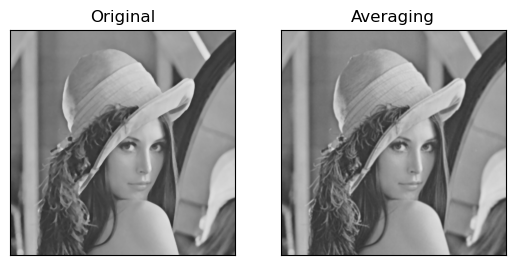

In [ ]:
kernel=np.ones((5,5),np.float32)/25
blur = cv2.GaussianBlur(img1,(5,5),0) #모든 값의 평균값
#dst=cv2.filter2D(img,-1,kernel)
median = cv2.medianBlur(img1,5) #모든 값의 중간값 (Bilateral 필터는 엣지가 깨지는 걸 막는 필터(여기엔 없음))
plt.subplot(121),plt.imshow(median),plt.title('Original')
plt.xticks([]),plt.yticks([])
plt.subplot(122),plt.imshow(blur),plt.title('Averaging')
plt.xticks([]),plt.yticks([])
plt.show()